# EuroSAT Land-Use Classification with ResNet-18

**Author:** Mark David Mapalo Mwila
**Date:** October 2026
**Course:** AI-driven Perception, Learning and Mapping for Drones (NPTEL / IISc)
**Module alignment:** Module 1 (foundations of neural networks), Module 2 (CNNs)

---

## Overview

Aerial/satellite image classification on the EuroSAT dataset (27,000 labeled
64×64 Sentinel-2 patches, 10 land-use classes). Built and evaluated a
pretrained ResNet-18, then ran controlled experiments (one change at a time)
to understand generalization, transfer learning, and the effect of key
training choices.

## Dataset

- **EuroSAT RGB**: 27,000 images, 10 classes, 64×64 pixels
- Split: 70% train / 15% val / 15% test (18,900 / 4,050 / 4,050)
- Fixed random seed (42) for a reproducible split

## Model (baseline)

- Pretrained ResNet-18 (ImageNet), final layer replaced with a 10-class head
- Adam optimizer, CrossEntropyLoss, batch size 64
- Hardware: Experiments 0-1 were originally run on CPU; Experiments 2-5 on a Colab T4 GPU

## Experiments and Results

| # | Experiment | Test Acc | Key Finding |
|---|---|---|---|
| 0 | Baseline, 10 epochs | 93.6% | Reference point |
| 1 | 20 epochs | 94.6% | No overfitting yet; the val curve is noisy |
| 2 | + Learning rate schedule | **97.8%** | LR schedule is the biggest single lever |
| 3 | Freeze conv1..layer2 (weak) | 96.7% | Small freeze costs ~1% (frozen BN stats still updated) |
| 3b | Freeze conv1..layer3 (strong) + BN-eval fix | 95.7% | More freezing, more cost |
| 4 | Remove augmentation | 96.5% | Augmentation prevents memorization (train hits 100%) |
| 5 | From-scratch CNN (~586K params) | 96.2% | Pretraining is worth ~1.6% on this easy dataset |

## Main takeaways

1. **The learning-rate schedule was the highest-leverage change.** Adding StepLR
   alone lifted accuracy from 94.6% to 97.8%.
2. **Augmentation prevents memorization.** Without it, the model hit
   100% training accuracy and the generalization gap grew ~9×.
3. **Transfer learning helps, but not dramatically on easy datasets.**
   Pretraining saved ~1.6% accuracy and much time to converge, but a
   small from-scratch CNN was competitive.
4. **Freezing is a trade-off, not a free win.** Freezing ~6% of parameters cost ~1%;
   freezing ~25% cost ~2% (versus full fine-tuning).

## Caveats

- Each configuration was run once. Only the data split is seeded in the original runs.
- With a 4,050-image test set, the standard error is roughly ±0.3% (about ±0.5% at 95%),
  so the 3.2% LR gain is clearly real, while differences of ~1% are suggestive, not proven.
- Experiments 3 and 3b differ in two ways (extra frozen layer *and* the BatchNorm-eval fix),
  so that comparison is not a single-variable change.

## Reproducing

- Set the runtime to **GPU** (Runtime → Change runtime type → T4), then Runtime → Run all (about 25 minutes).
- The log cells hold the **original** results. A rerun will land close to them but not match exactly;
  the last cell prints both side by side.
- Set `TAG = "_rerun"` in the setup cell to avoid overwriting the original checkpoints and logs on Drive.

## Log files (in /content/drive/MyDrive/eurosat/)

- exp0_baseline_10ep.txt
- exp1_20ep.txt
- exp2_lr_schedule.txt
- exp3_weak_freeze.txt
- exp3b_strong_freeze.txt
- exp4_augmentation_ablation.txt
- exp5_fromscratch_cnn.txt

Model checkpoints (.pt) are also in that folder.

## Setup

One-time setup: imports, Drive, data, and helper functions shared by every experiment.

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import random_split, DataLoader
from torchvision.datasets import EuroSAT
from torchvision import transforms, models

# --- Device ---
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device,
      "|", torch.cuda.get_device_name(0) if device == "cuda" else "CPU only (switch the runtime to GPU)")

# --- Output folder (Drive on Colab, local folder elsewhere) ---
try:
    from google.colab import drive
    drive.mount("/content/drive")
    OUT_DIR = "/content/drive/MyDrive/eurosat"
except ImportError:
    OUT_DIR = "./eurosat_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

SEED = 42
TAG = ""   # set to "_rerun" to avoid overwriting the original checkpoints and logs
results = {}   # filled in by evaluate(); compared with the original numbers at the end

device: cuda | Tesla T4
Mounted at /content/drive


In [ ]:
# --- Dataset and 70/15/15 split (seed 42 -> identical split every run) ---
base = EuroSAT(root="./data", download=True, transform=None)

N = len(base)                  # 27000
n_train = int(0.70 * N)        # 18900
n_val   = int(0.15 * N)        # 4050
n_test  = N - n_train - n_val  # 4050

train_sub, val_sub, test_sub = random_split(
    base, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED),
)

# EuroSAT RGB channel means/stds
MEAN = [0.3444, 0.3803, 0.4078]
STD  = [0.2037, 0.1366, 0.1148]

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

class WithTransform(torch.utils.data.Dataset):
    """Apply a transform to a Subset (random_split subsets share the raw dataset)."""
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        return self.transform(img), label

# Augmented training loader (Experiments 0-3b and 5)
train_loader = DataLoader(WithTransform(train_sub, train_transform),
                          batch_size=64, shuffle=True, num_workers=2)
# Un-augmented training loader (Experiment 4 only)
train_loader_noaug = DataLoader(WithTransform(train_sub, eval_transform),
                                batch_size=64, shuffle=True, num_workers=2)
# Validation and test never use augmentation
val_loader  = DataLoader(WithTransform(val_sub,  eval_transform),
                         batch_size=64, shuffle=False, num_workers=2)
test_loader = DataLoader(WithTransform(test_sub, eval_transform),
                         batch_size=64, shuffle=False, num_workers=2)

# Sanity check
x, y = next(iter(train_loader))
print(x.shape, y.shape)   # torch.Size([64, 3, 64, 64]) torch.Size([64])

100%|██████████| 94.3M/94.3M [00:02<00:00, 44.8MB/s]


torch.Size([64, 3, 64, 64]) torch.Size([64])


In [ ]:
# --- Helpers shared by every experiment ---
criterion = nn.CrossEntropyLoss()

def set_seed(seed=SEED):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def build_resnet18(frozen_prefixes=()):
    """Pretrained ResNet-18 with a 10-class head; parameters whose names start
    with any of frozen_prefixes get requires_grad=False."""
    m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    m.fc = nn.Linear(m.fc.in_features, 10)
    if frozen_prefixes:
        for name, p in m.named_parameters():
            if name.startswith(tuple(frozen_prefixes)):
                p.requires_grad = False
    return m.to(device)

def make_optimizer(model, lr=1e-3):
    # Only trainable parameters go to the optimizer (matters when layers are frozen)
    return optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)

def param_report(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total {total:,} | trainable {trainable:,} ({trainable/total:.1%}) | frozen {total-trainable:,}")

def run_epoch(model, loader, criterion, optimizer=None, frozen_bn_prefixes=()):
    """One pass over loader. optimizer=None -> evaluation, otherwise training.
    frozen_bn_prefixes: BatchNorm layers whose name starts with these stay in eval()
    mode during training so their running statistics do not drift."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    if is_train and frozen_bn_prefixes:
        for name, module in model.named_modules():
            if isinstance(module, nn.BatchNorm2d) and name.startswith(tuple(frozen_bn_prefixes)):
                module.eval()

    total_loss = total_correct = total_samples = 0
    with torch.enable_grad() if is_train else torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * y.size(0)
            total_correct += (logits.argmax(1) == y).sum().item()
            total_samples += y.size(0)
    return total_loss / total_samples, total_correct / total_samples

def fit(model, optimizer, epochs, train_dl, scheduler=None, frozen_bn_prefixes=()):
    """Train for `epochs`, validating after each one. Returns the history dict."""
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = run_epoch(model, train_dl, criterion, optimizer, frozen_bn_prefixes)
        va_loss, va_acc = run_epoch(model, val_loader, criterion)
        if scheduler is not None:
            scheduler.step()
        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc);   history["val_acc"].append(va_acc)
        lr_now = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch:2d}/{epochs} | lr {lr_now:.2e} | "
              f"train loss {tr_loss:.3f} acc {tr_acc:.3f} | "
              f"val loss {va_loss:.3f} acc {va_acc:.3f}")
    return history

def plot_history(history, title):
    ep = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, key, label in [(axes[0], "loss", "Loss"), (axes[1], "acc", "Accuracy")]:
        ax.plot(ep, history["train_" + key], marker="o", label="train")
        ax.plot(ep, history["val_" + key],   marker="o", label="val")
        ax.set_xlabel("Epoch"); ax.set_ylabel(label)
        ax.set_title(f"{label} ({title})"); ax.legend(); ax.grid(True)
    plt.tight_layout(); plt.show()

def evaluate(model, name):
    """Test-set evaluation; stores the accuracy in `results`."""
    loss, acc = run_epoch(model, test_loader, criterion)
    results[name] = acc
    print(f"[{name}] Test loss {loss:.3f} | Test accuracy {acc:.3f}")
    return loss, acc

def _out_path(filename):
    stem, ext = os.path.splitext(filename)
    return os.path.join(OUT_DIR, f"{stem}{TAG}{ext}")

def save_checkpoint(model, filename):
    torch.save(model.state_dict(), _out_path(filename))
    print("Saved", _out_path(filename))

def write_log(filename, text):
    with open(_out_path(filename), "w") as f:
        f.write(text)
    print("Wrote", _out_path(filename))

## Experiment 0: Baseline (10 epochs)

**Change vs nothing:** this is the baseline. Pretrained ResNet-18, 10 epochs, augmentation on.

**Question:** What does a straightforward pretrained model achieve on EuroSAT with a fixed learning rate?

**Setup:**
- Model: ResNet-18 (pretrained ImageNet), fc replaced with a 10-class head
- Augmentation: RandomHorizontalFlip, RandomVerticalFlip, RandomRotation(90)
- Optimizer: Adam, lr=1e-3 (fixed, no scheduler)
- Epochs: 10
- No freezing

**Result:** Test accuracy **93.6%**

**Observations:**
- No overfitting: train and val track closely throughout.
- Val spike at epoch 6 (val loss 0.33) recovered by epoch 7. This is variance, not overfitting.
- Train accuracy was still improving at epoch 10, motivating a longer run.

In [ ]:
set_seed()
model = build_resnet18()
optimizer = make_optimizer(model, lr=1e-3)
history = fit(model, optimizer, epochs=10, train_dl=train_loader)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 177MB/s]


Epoch  1/10 | lr 1.00e-03 | train loss 0.476 acc 0.845 | val loss 0.367 acc 0.886
Epoch  2/10 | lr 1.00e-03 | train loss 0.306 acc 0.900 | val loss 0.361 acc 0.888
Epoch  3/10 | lr 1.00e-03 | train loss 0.262 acc 0.914 | val loss 0.239 acc 0.920
Epoch  4/10 | lr 1.00e-03 | train loss 0.231 acc 0.924 | val loss 0.205 acc 0.934
Epoch  5/10 | lr 1.00e-03 | train loss 0.207 acc 0.929 | val loss 0.213 acc 0.927
Epoch  6/10 | lr 1.00e-03 | train loss 0.202 acc 0.932 | val loss 0.313 acc 0.902
Epoch  7/10 | lr 1.00e-03 | train loss 0.198 acc 0.933 | val loss 0.393 acc 0.884
Epoch  8/10 | lr 1.00e-03 | train loss 0.193 acc 0.938 | val loss 0.154 acc 0.950
Epoch  9/10 | lr 1.00e-03 | train loss 0.194 acc 0.939 | val loss 0.228 acc 0.923
Epoch 10/10 | lr 1.00e-03 | train loss 0.158 acc 0.946 | val loss 0.185 acc 0.949


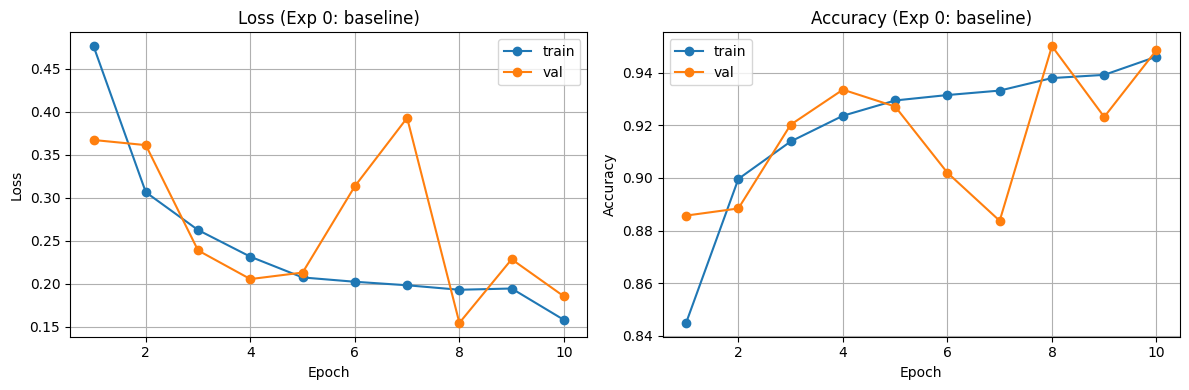

[Exp 0] Test loss 0.192 | Test accuracy 0.941
Saved /content/drive/MyDrive/eurosat/resnet18_93.6.pt


In [ ]:
plot_history(history, "Exp 0: baseline")
evaluate(model, "Exp 0")
save_checkpoint(model, "resnet18_93.6.pt")

In [ ]:
exp0 = """EXPERIMENT 0 - BASELINE, 10 EPOCHS
====================================

Model:        ResNet-18 (pretrained ImageNet), fc replaced with 10-class head
Dataset:      EuroSAT RGB, 27,000 images, 64x64, 10 classes
Split:        70/15/15 train/val/test (seed=42) -> 18,900 / 4,050 / 4,050
Optimizer:    Adam, lr=1e-3
Loss:         CrossEntropyLoss
Batch size:   64
Augmentation: RandomHorizontalFlip, RandomVerticalFlip, RandomRotation(90)
              Normalize(mean=[0.3444,0.3803,0.4078], std=[0.2037,0.1366,0.1148])
Device:       CPU (Colab default)

Purpose:
    Establish baseline test accuracy with a pretrained ResNet-18 fine-tuned
    on EuroSAT for 10 epochs.

Runtime:
    ~1h 15m (CPU)

Result:
    Test loss     0.205
    Test accuracy 0.936 (93.6%)

Per-epoch:
    Epoch  1/10 | train loss 0.497 acc 0.845 | val loss 0.360 acc 0.882
    Epoch  2/10 | train loss 0.309 acc 0.899 | val loss 0.393 acc 0.883
    Epoch  3/10 | train loss 0.268 acc 0.910 | val loss 0.178 acc 0.941
    Epoch  4/10 | train loss 0.231 acc 0.923 | val loss 0.177 acc 0.942
    Epoch  5/10 | train loss 0.237 acc 0.920 | val loss 0.188 acc 0.942
    Epoch  6/10 | train loss 0.204 acc 0.932 | val loss 0.331 acc 0.899
    Epoch  7/10 | train loss 0.184 acc 0.938 | val loss 0.205 acc 0.934
    Epoch  8/10 | train loss 0.180 acc 0.939 | val loss 0.166 acc 0.944
    Epoch  9/10 | train loss 0.186 acc 0.940 | val loss 0.174 acc 0.942
    Epoch 10/10 | train loss 0.169 acc 0.943 | val loss 0.213 acc 0.930

Observations:
    - No overfitting: train and val track closely throughout.
    - Val curve has a spike at epoch 6 (val loss 0.33, val acc 0.899)
      that recovers by epoch 7. This is variance, not overfitting.
    - Train accuracy was still improving at epoch 10, motivating a
      longer run (Experiment 1).

Saved model: resnet18_93.6.pt
"""
write_log("exp0_baseline_10ep.txt", exp0)

Wrote /content/drive/MyDrive/eurosat/exp0_baseline_10ep.txt


## Experiment 1: Train Longer (20 epochs)

**Change vs Experiment 0:** double the epochs (10 → 20). Everything else identical.

**Question:** Does more training improve accuracy, and where (if anywhere) does overfitting begin?

**Setup:** same as Experiment 0, but 20 epochs.

**Result:** Test accuracy **94.6%** (+1.0% vs baseline)

**Observations:**
- No overfitting even at 20 epochs: train accuracy climbs smoothly to ~95%, and val swings up to 5% epoch-to-epoch but trends flat-to-slightly-up.
- Train loss is smooth; val loss spikes at epochs 5, 10, 13 and recovers each time.
- Diagnosis: the noisy val curve is a **variance problem**, not a generalization problem.
- Likely causes: small val set (4,050 images), BatchNorm running stats still settling, augmentation.

**Conclusion:** Longer training helps a little. The real actionable insight is that the LR is probably too high late in training, motivating a scheduler.

In [ ]:
set_seed()
model = build_resnet18()
optimizer = make_optimizer(model, lr=1e-3)
history = fit(model, optimizer, epochs=20, train_dl=train_loader)

Epoch  1/20 | lr 1.00e-03 | train loss 0.477 acc 0.847 | val loss 0.291 acc 0.910
Epoch  2/20 | lr 1.00e-03 | train loss 0.310 acc 0.900 | val loss 0.307 acc 0.902
Epoch  3/20 | lr 1.00e-03 | train loss 0.269 acc 0.911 | val loss 0.271 acc 0.911
Epoch  4/20 | lr 1.00e-03 | train loss 0.227 acc 0.925 | val loss 0.191 acc 0.939
Epoch  5/20 | lr 1.00e-03 | train loss 0.211 acc 0.930 | val loss 0.196 acc 0.939
Epoch  6/20 | lr 1.00e-03 | train loss 0.205 acc 0.932 | val loss 0.244 acc 0.920
Epoch  7/20 | lr 1.00e-03 | train loss 0.196 acc 0.935 | val loss 0.211 acc 0.929
Epoch  8/20 | lr 1.00e-03 | train loss 0.178 acc 0.942 | val loss 0.174 acc 0.939
Epoch  9/20 | lr 1.00e-03 | train loss 0.183 acc 0.939 | val loss 0.281 acc 0.907
Epoch 10/20 | lr 1.00e-03 | train loss 0.169 acc 0.944 | val loss 0.175 acc 0.943
Epoch 11/20 | lr 1.00e-03 | train loss 0.146 acc 0.951 | val loss 0.164 acc 0.948
Epoch 12/20 | lr 1.00e-03 | train loss 0.186 acc 0.940 | val loss 0.155 acc 0.950
Epoch 13/20 | lr

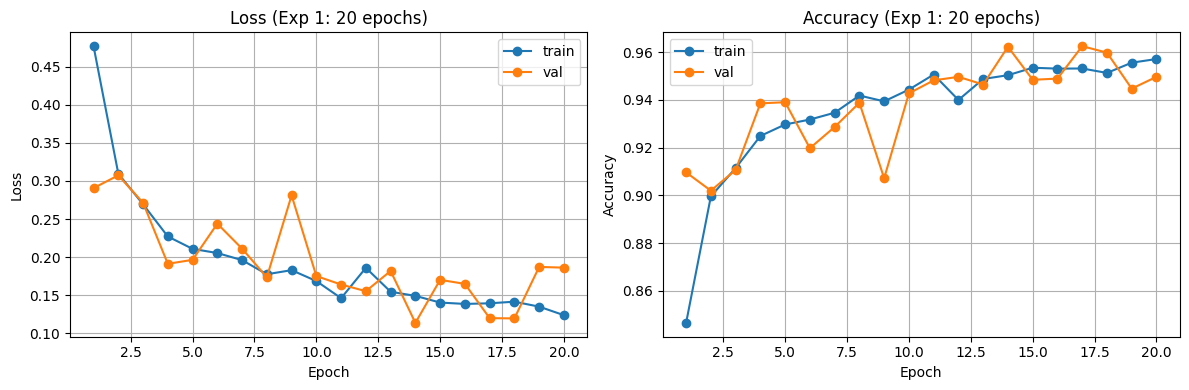

[Exp 1] Test loss 0.159 | Test accuracy 0.954
Saved /content/drive/MyDrive/eurosat/resnet18_20ep.pt


In [ ]:
plot_history(history, "Exp 1: 20 epochs")
evaluate(model, "Exp 1")
save_checkpoint(model, "resnet18_20ep.pt")

In [ ]:
exp1 = """EXPERIMENT 1 - TRAIN LONGER, 20 EPOCHS
======================================

Purpose:
    Test whether doubling training length (10 -> 20 epochs) improves
    accuracy, and observe where (or whether) overfitting begins.

Setup:
    Identical to Experiment 0, except EPOCHS = 20.

Runtime:
    ~2h 13m (CPU)

Result:
    Test loss     0.179
    Test accuracy 0.946 (94.6%)    [ +1.0% over Experiment 0 ]

Observations:
    - NO OVERFITTING, even at 20 epochs.
        * Train accuracy climbs smoothly to ~95%.
        * Val accuracy swings up to 5 percentage points epoch-to-epoch,
          but its trend is flat-to-slightly-up. No sustained divergence.
        * Train loss is smooth; val loss spikes at epochs 5, 10, 13
          and recovers each time.

    - Diagnosis: the noisy val curve is a VARIANCE problem, not a
      generalization problem.

    - Likely causes of val noise:
        (a) Small val set (4,050 images) -> noisy averages.
        (b) BatchNorm running statistics still settling.
        (c) Aggressive augmentation creates mild train/val mismatch.

Conclusion:
    Longer training gave a modest gain (+1.0%) and confirmed the model
    is not yet overfitting. The main actionable insight is that the
    learning rate is likely too high in late epochs, causing the model
    to bounce around rather than settle. This motivates Experiment 2:
    add a learning rate scheduler.

Saved model: resnet18_20ep.pt
"""
write_log("exp1_20ep.txt", exp1)

Wrote /content/drive/MyDrive/eurosat/exp1_20ep.txt


## Experiment 2: Learning Rate Schedule

**Change vs Experiment 1:** add `StepLR(step_size=7, gamma=0.3)`. Same model, same 20 epochs, same augmentation.

**Question:** Does reducing the learning rate in later epochs smooth the noisy val curve and improve accuracy?

**Setup:**
- LR schedule: 1e-3 for epochs 1-7, 3e-4 for 8-14, 9e-5 for 15-20.

**Result:** Test accuracy **97.8%** (+3.2% vs Experiment 1)

**Observations:**
- The noisy val curve is nearly gone. Second-half val accuracy is tight (0.966-0.979).
- The moment LR drops to 3e-4 (epoch 8), val loss falls from 0.23 to 0.094 in one epoch.
- No overfitting: final train 0.982 vs val 0.979, gap ~0.3%.

**Conclusion:** The learning-rate schedule was the highest-leverage change on this dataset. It lets the model settle in later epochs, unlocking an accuracy regime the fixed-LR runs never reached. This is the reference run for Experiments 3-5.

In [ ]:
set_seed()
model = build_resnet18()
optimizer = make_optimizer(model, lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.3)   # the only change vs Exp 1
history = fit(model, optimizer, epochs=20, train_dl=train_loader, scheduler=scheduler)

Epoch  1/20 | lr 1.00e-03 | train loss 0.475 acc 0.848 | val loss 0.286 acc 0.910
Epoch  2/20 | lr 1.00e-03 | train loss 0.298 acc 0.902 | val loss 0.279 acc 0.910
Epoch  3/20 | lr 1.00e-03 | train loss 0.267 acc 0.914 | val loss 0.252 acc 0.917
Epoch  4/20 | lr 1.00e-03 | train loss 0.232 acc 0.923 | val loss 0.203 acc 0.933
Epoch  5/20 | lr 1.00e-03 | train loss 0.205 acc 0.932 | val loss 0.210 acc 0.936
Epoch  6/20 | lr 1.00e-03 | train loss 0.209 acc 0.931 | val loss 0.257 acc 0.920
Epoch  7/20 | lr 3.00e-04 | train loss 0.205 acc 0.933 | val loss 0.168 acc 0.946
Epoch  8/20 | lr 3.00e-04 | train loss 0.114 acc 0.961 | val loss 0.088 acc 0.968
Epoch  9/20 | lr 3.00e-04 | train loss 0.102 acc 0.965 | val loss 0.084 acc 0.968
Epoch 10/20 | lr 3.00e-04 | train loss 0.093 acc 0.968 | val loss 0.121 acc 0.960
Epoch 11/20 | lr 3.00e-04 | train loss 0.090 acc 0.968 | val loss 0.109 acc 0.964
Epoch 12/20 | lr 3.00e-04 | train loss 0.095 acc 0.965 | val loss 0.099 acc 0.967
Epoch 13/20 | lr

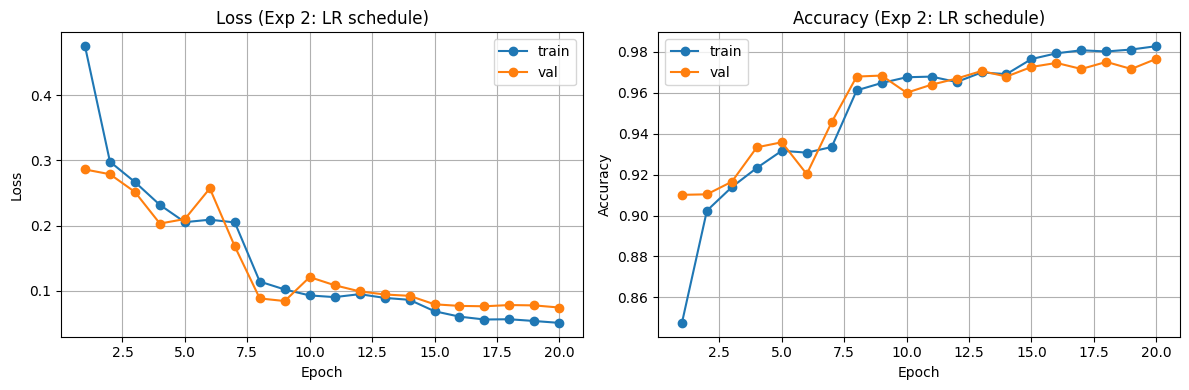

[Exp 2] Test loss 0.073 | Test accuracy 0.975
Saved /content/drive/MyDrive/eurosat/resnet18_20ep_lrsched.pt


In [ ]:
plot_history(history, "Exp 2: LR schedule")
evaluate(model, "Exp 2")
save_checkpoint(model, "resnet18_20ep_lrsched.pt")

In [ ]:
exp2 = """EXPERIMENT 2 - LEARNING RATE SCHEDULE
========================================

Purpose:
    Test whether reducing the learning rate in later epochs smooths
    the noisy validation curve observed in Experiment 1, and whether
    it improves final accuracy.

Setup:
    Same as Experiment 1 (ResNet-18 pretrained, 20 epochs, Adam,
    augmentation on), plus:
        scheduler = StepLR(optimizer, step_size=7, gamma=0.3)
    LR schedule: 1e-3 for epochs 1-7, 3e-4 for 8-14, 9e-5 for 15-20.

Runtime:
    ~2-3 minutes (GPU)

Result:
    Test loss     0.065
    Test accuracy 0.978  (97.8%)    [ +3.2% over Experiment 1, +4.2% over baseline ]

Per-epoch:
    Epoch  1/20 | lr 1.00e-03 | train loss 0.483 acc 0.846 | val loss 0.329 acc 0.890
    Epoch  2/20 | lr 1.00e-03 | train loss 0.313 acc 0.897 | val loss 0.207 acc 0.931
    Epoch  3/20 | lr 1.00e-03 | train loss 0.270 acc 0.911 | val loss 0.305 acc 0.900
    Epoch  4/20 | lr 1.00e-03 | train loss 0.236 acc 0.921 | val loss 0.248 acc 0.926
    Epoch  5/20 | lr 1.00e-03 | train loss 0.227 acc 0.925 | val loss 0.195 acc 0.936
    Epoch  6/20 | lr 1.00e-03 | train loss 0.200 acc 0.935 | val loss 0.185 acc 0.948
    Epoch  7/20 | lr 3.00e-04 | train loss 0.191 acc 0.936 | val loss 0.230 acc 0.931
    Epoch  8/20 | lr 3.00e-04 | train loss 0.126 acc 0.958 | val loss 0.094 acc 0.972
    Epoch  9/20 | lr 3.00e-04 | train loss 0.099 acc 0.966 | val loss 0.087 acc 0.970
    Epoch 10/20 | lr 3.00e-04 | train loss 0.092 acc 0.968 | val loss 0.100 acc 0.966
    Epoch 11/20 | lr 3.00e-04 | train loss 0.095 acc 0.968 | val loss 0.086 acc 0.976
    Epoch 12/20 | lr 3.00e-04 | train loss 0.089 acc 0.970 | val loss 0.107 acc 0.966
    Epoch 13/20 | lr 3.00e-04 | train loss 0.091 acc 0.968 | val loss 0.105 acc 0.968
    Epoch 14/20 | lr 9.00e-05 | train loss 0.091 acc 0.969 | val loss 0.104 acc 0.971
    Epoch 15/20 | lr 9.00e-05 | train loss 0.064 acc 0.977 | val loss 0.078 acc 0.976
    Epoch 16/20 | lr 9.00e-05 | train loss 0.058 acc 0.980 | val loss 0.078 acc 0.980
    Epoch 17/20 | lr 9.00e-05 | train loss 0.058 acc 0.979 | val loss 0.089 acc 0.975
    Epoch 18/20 | lr 9.00e-05 | train loss 0.054 acc 0.981 | val loss 0.073 acc 0.978
    Epoch 19/20 | lr 9.00e-05 | train loss 0.052 acc 0.980 | val loss 0.072 acc 0.978
    Epoch 20/20 | lr 9.00e-05 | train loss 0.050 acc 0.982 | val loss 0.073 acc 0.979

Observations:
    - MAJOR improvement: +3.2% test accuracy from a single-line change.
    - The noisy val curve from Experiment 1 is nearly gone. Second-half
      val accuracy is tight (0.966-0.979) compared to Exp 1's swings.
    - The moment the LR drops from 1e-3 to 3e-4 (epoch 8), val loss
      collapses from 0.23 to 0.094 in a single epoch. The model was
      previously bouncing out of good minima every step.
    - No overfitting: final train acc 0.982 vs val acc 0.979, gap ~0.3%.

Conclusion:
    Learning rate is arguably the most important hyperparameter. A
    schedule that lets the model "settle in" in later epochs unlocked
    a full accuracy regime the fixed-LR runs never reached.

    This is the strongest result so far and will be the reference
    baseline for Experiments 3-5.

Saved model: resnet18_20ep_lrsched.pt
"""
write_log("exp2_lr_schedule.txt", exp2)

Wrote /content/drive/MyDrive/eurosat/exp2_lr_schedule.txt


## Experiment 3: Weak Freeze (conv1..layer2)

**Change vs Experiment 2:** freeze `conv1`, `bn1`, `layer1`, `layer2`. Only `layer3`, `layer4`, `fc` train.

**Question:** Do the early pretrained layers already encode what EuroSAT needs? If frozen, do we keep the same accuracy while updating fewer parameters?

**Setup:**
- Frozen: conv1, bn1, layer1, layer2 (only ~6% of params, since the early blocks are small)
- Trained: layer3, layer4, fc (~94%)
- Same LR schedule as Experiment 2
- As originally run, the frozen BatchNorm layers were *not* put in eval mode, so their running statistics kept updating (fixed in 3b)

**Result:** Test accuracy **96.7%** (-1.1% vs Experiment 2)

**Observations:**
- Freezing even a small fraction of parameters cost accuracy.
- The early layers were not strictly necessary, but they still contributed.

**Conclusion:** Freezing is a trade-off, not a free win. ImageNet's earliest layers learn natural-photo statistics, and EuroSAT's satellite imagery benefits slightly from letting them adapt.

In [13]:
set_seed()
FROZEN_3 = ("conv1", "bn1", "layer1", "layer2")
model = build_resnet18(frozen_prefixes=FROZEN_3)
param_report(model)
optimizer = make_optimizer(model, lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.3)
# frozen_bn_prefixes is left empty on purpose: this reproduces the original Exp 3 run.
# To test the BN-eval fix on Exp 3, pass frozen_bn_prefixes=FROZEN_3 here.
history = fit(model, optimizer, epochs=20, train_dl=train_loader, scheduler=scheduler)

Total 11,181,642 | trainable 10,498,570 (93.9%) | frozen 683,072
Epoch  1/20 | lr 1.00e-03 | train loss 0.444 acc 0.854 | val loss 0.266 acc 0.908
Epoch  2/20 | lr 1.00e-03 | train loss 0.291 acc 0.902 | val loss 0.237 acc 0.920
Epoch  3/20 | lr 1.00e-03 | train loss 0.253 acc 0.916 | val loss 0.191 acc 0.931
Epoch  4/20 | lr 1.00e-03 | train loss 0.226 acc 0.923 | val loss 0.163 acc 0.945
Epoch  5/20 | lr 1.00e-03 | train loss 0.203 acc 0.934 | val loss 0.180 acc 0.941
Epoch  6/20 | lr 1.00e-03 | train loss 0.194 acc 0.933 | val loss 0.156 acc 0.949
Epoch  7/20 | lr 3.00e-04 | train loss 0.187 acc 0.937 | val loss 0.156 acc 0.950
Epoch  8/20 | lr 3.00e-04 | train loss 0.133 acc 0.954 | val loss 0.108 acc 0.963
Epoch  9/20 | lr 3.00e-04 | train loss 0.120 acc 0.958 | val loss 0.099 acc 0.968
Epoch 10/20 | lr 3.00e-04 | train loss 0.113 acc 0.959 | val loss 0.101 acc 0.968
Epoch 11/20 | lr 3.00e-04 | train loss 0.107 acc 0.962 | val loss 0.103 acc 0.965
Epoch 12/20 | lr 3.00e-04 | train

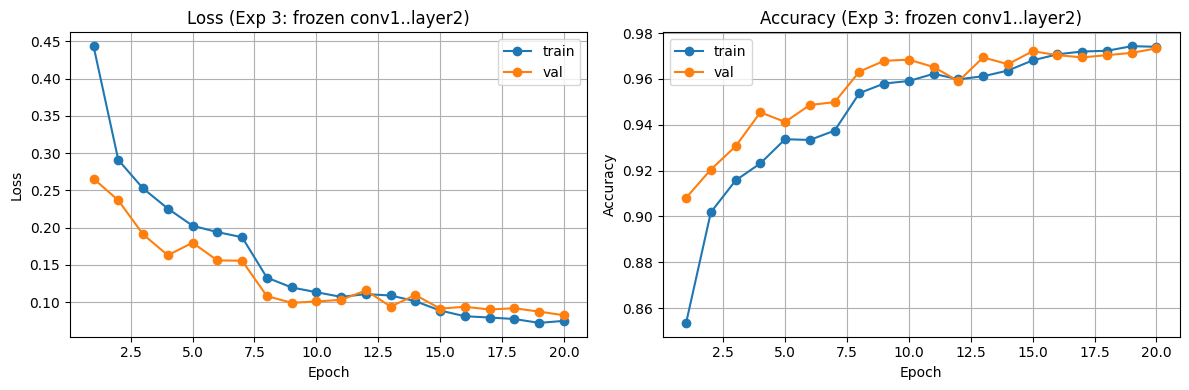

[Exp 3] Test loss 0.092 | Test accuracy 0.968
Saved /content/drive/MyDrive/eurosat/resnet18_frozen_early.pt


In [14]:
plot_history(history, "Exp 3: frozen conv1..layer2")
evaluate(model, "Exp 3")
save_checkpoint(model, "resnet18_frozen_early.pt")

In [15]:
exp3 = """EXPERIMENT 3 - WEAK FREEZE (conv1..layer2)
============================================

Purpose:
    Test whether the earliest pretrained layers already encode what
    EuroSAT needs, by freezing them and training only layer3, layer4
    and fc.

Setup:
    Same as Experiment 2 (ResNet-18 pretrained, 20 epochs, Adam
    lr=1e-3, StepLR step_size=7 gamma=0.3, augmentation on), plus:
    Frozen:     conv1, bn1, layer1, layer2   (~6% of params)
    Trained:    layer3, layer4, fc           (~94% of params)
    Note:       frozen BatchNorm layers were NOT put in eval() mode,
                so their running statistics kept updating during
                training (this was fixed in Experiment 3b).

Result:
    Test accuracy 0.967  (96.7%)    [ -1.1% vs Experiment 2 ]
    (Test loss and per-epoch values are not recorded in this log.)

Observations:
    - Freezing even a small fraction of the parameters cost accuracy.
    - The early layers were not strictly necessary, but they still
      contributed.

Conclusion:
    Freezing is a trade-off, not a free win. ImageNet's earliest layers
    learn natural-photo statistics, and EuroSAT's satellite imagery
    benefits slightly from letting them adapt.

Saved model: resnet18_frozen_early.pt
"""
write_log("exp3_weak_freeze.txt", exp3)

Wrote /content/drive/MyDrive/eurosat/exp3_weak_freeze.txt


## Experiment 3b: Strong Freeze (conv1..layer3)

**Change vs Experiment 3:** also freeze `layer3`. Frozen: conv1, bn1, layer1, layer2, layer3 (~25% of params). Trained: layer4 + fc (~75%).

**Also changed:** frozen BatchNorm layers are kept in `eval()` mode during training so their running stats do not drift. (In Experiment 3 they quietly kept adapting.)

**Caveat:** because two things changed at once (more freezing *and* the BN fix), the Exp 3 → 3b comparison is not a clean single-variable test.

**Question:** Does freezing ~25% of the network still reach ~95-97% accuracy?

**Result:** Test accuracy **95.7%** (-2.1% vs Experiment 2, -1.0% vs Experiment 3)

**Observations:**
- Monotonic trend across the three runs: more freezing, lower accuracy.
- Roughly 1% lost per 20% of the network frozen on this dataset (suggestive, single runs).
- No overfitting: train and val curves overlap throughout.

**Conclusion:** Transfer learning is a real trade-off on EuroSAT. The pretrained early layers are useful but not perfect for satellite imagery. Freezing is worth it when compute or memory matters, but it costs a measurable amount of accuracy.

In [16]:
set_seed()
FROZEN_3B = ("conv1", "bn1", "layer1", "layer2", "layer3")
model = build_resnet18(frozen_prefixes=FROZEN_3B)
param_report(model)
optimizer = make_optimizer(model, lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.3)
history = fit(model, optimizer, epochs=20, train_dl=train_loader, scheduler=scheduler,
              frozen_bn_prefixes=FROZEN_3B)   # BN-eval fix

Total 11,181,642 | trainable 8,398,858 (75.1%) | frozen 2,782,784
Epoch  1/20 | lr 1.00e-03 | train loss 0.464 acc 0.840 | val loss 0.332 acc 0.889
Epoch  2/20 | lr 1.00e-03 | train loss 0.321 acc 0.887 | val loss 0.246 acc 0.917
Epoch  3/20 | lr 1.00e-03 | train loss 0.281 acc 0.902 | val loss 0.260 acc 0.914
Epoch  4/20 | lr 1.00e-03 | train loss 0.261 acc 0.909 | val loss 0.214 acc 0.926
Epoch  5/20 | lr 1.00e-03 | train loss 0.247 acc 0.916 | val loss 0.183 acc 0.937
Epoch  6/20 | lr 1.00e-03 | train loss 0.234 acc 0.917 | val loss 0.190 acc 0.934
Epoch  7/20 | lr 3.00e-04 | train loss 0.219 acc 0.924 | val loss 0.191 acc 0.937
Epoch  8/20 | lr 3.00e-04 | train loss 0.180 acc 0.935 | val loss 0.154 acc 0.950
Epoch  9/20 | lr 3.00e-04 | train loss 0.167 acc 0.938 | val loss 0.148 acc 0.949
Epoch 10/20 | lr 3.00e-04 | train loss 0.160 acc 0.942 | val loss 0.138 acc 0.955
Epoch 11/20 | lr 3.00e-04 | train loss 0.153 acc 0.945 | val loss 0.138 acc 0.953
Epoch 12/20 | lr 3.00e-04 | trai

In [ ]:
plot_history(history, "Exp 3b: frozen conv1..layer3")
evaluate(model, "Exp 3b")
save_checkpoint(model, "resnet18_frozen_layer3.pt")

In [ ]:
exp3b = """EXPERIMENT 3b - STRONG FREEZE (conv1..layer3)
==============================================

Purpose:
    Test whether freezing ~25% of ResNet-18's parameters (conv1, bn1,
    layer1, layer2, layer3) still reaches ~95-97% test accuracy. Also
    fix a subtle issue from Experiment 3: frozen BatchNorm layers were
    still updating their running stats during training.

Setup:
    Model:      ResNet-18 (pretrained ImageNet), fc replaced with 10-class head
    Frozen:     conv1, bn1, layer1, layer2, layer3   (25% of params, ~2.78M)
    Trained:    layer4, fc                           (75% of params, ~8.40M)
    Fix:        frozen BatchNorm layers kept in eval() mode during training
    Optimizer:  Adam, lr=1e-3 (only trainable params)
    Scheduler:  StepLR(step_size=7, gamma=0.3)
    Epochs:     20
    Runtime:    ~5 minutes (GPU)

Result:
    Test loss     0.121  (approx)
    Test accuracy 0.957  (95.7%)

Comparison:
    Experiment 2  (no freeze, 100% trained) : 97.8%
    Experiment 3  (weak freeze, 94% trained): 96.7%
    Experiment 3b (strong freeze, 75% trained): 95.7%

Observations:
    - Clean monotonic trend: more freezing -> slightly lower accuracy.
      Roughly 1% loss per 20% of the network frozen on this dataset.
    - No overfitting: train and val curves overlap throughout.
    - Both curves still improving slowly at epoch 20; more epochs could
      gain a bit more.
    - Val is smoother than Experiment 2 early on (likely due to the BN
      fix in the frozen layers, plus the smaller trainable set).

Conclusion:
    Transfer learning is a real trade-off on EuroSAT. The pretrained
    early layers are useful but not perfect for satellite imagery;
    fine-tuning them yields a small but measurable gain. Freezing is
    still worth it when compute/memory matters - the ~2% accuracy cost
    is small compared to the practical benefits.

Saved model: resnet18_frozen_layer3.pt
"""
write_log("exp3b_strong_freeze.txt", exp3b)

## Experiment 4: Augmentation Ablation

**Change vs Experiment 2:** remove augmentation. Training images get only `ToTensor` + `Normalize`, the same as validation.

**Question:** How much does augmentation actually buy us on EuroSAT? Does removing it cause overfitting?

**Setup:**
- Same model, optimizer, scheduler, and 20 epochs as Experiment 2.
- Only difference: the training loader is `train_loader_noaug` (no flips, no rotation).

**Result:** Test accuracy **96.5%** (-1.3% vs Experiment 2)

**Observations:**
- Training accuracy hits **1.000** by epoch 16: perfect memorization of the training set.
- Validation accuracy plateaus around 0.97 and never breaks 0.975.
- Train loss reaches ~0.001 while val loss hovers at 0.10-0.13.
- The generalization gap grew from ~0.3% (Exp 2) to ~2.8% (Exp 4), about 9× larger.
- Val loss even *rises* slightly in epochs 11-14 while train loss keeps falling, the classic divergence signature.

**Conclusion:** Augmentation prevents memorization. On EuroSAT the accuracy cost of removing it is modest (1.3%) because the classes are visually distinct, but the generalization gap makes the mechanism visible. This is the clearest empirical demonstration of the "generalization" concept from Module 1.

In [ ]:
set_seed()
model = build_resnet18()
optimizer = make_optimizer(model, lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.3)
history = fit(model, optimizer, epochs=20, train_dl=train_loader_noaug, scheduler=scheduler)

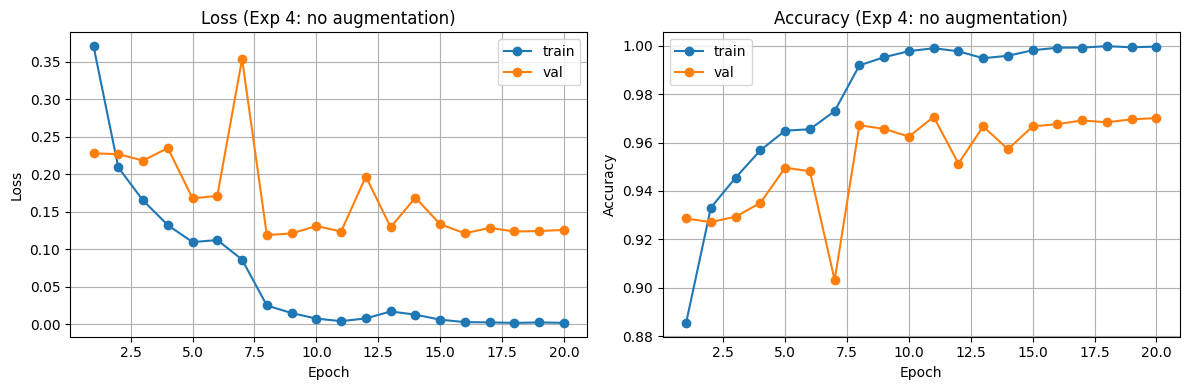

[Exp 4] Test loss 0.126 | Test accuracy 0.970
Saved /content/drive/MyDrive/eurosat/resnet18_noaug.pt


In [20]:
plot_history(history, "Exp 4: no augmentation")
evaluate(model, "Exp 4")
save_checkpoint(model, "resnet18_noaug.pt")

In [ ]:
exp4 = """EXPERIMENT 4 - AUGMENTATION ABLATION
=======================================

Purpose:
    Measure how much the training augmentation (horizontal flip,
    vertical flip, 90-degree rotation) actually contributes on EuroSAT.
    Test whether removing it causes overfitting.

Setup:
    Identical to Experiment 2 (ResNet-18 pretrained, 20 epochs, Adam
    lr=1e-3, StepLR step_size=7 gamma=0.3, no freeze), EXCEPT the
    training transform is reduced to just ToTensor + Normalize --
    the same transform used for validation and test.

    Train transform:  ToTensor -> Normalize
    Eval transform:   ToTensor -> Normalize  (unchanged)

Runtime:
    ~5 minutes (GPU)

Result:
    Test loss     0.156
    Test accuracy 0.965  (96.5%)

Comparison to Experiment 2 (with augmentation):
    Exp 2 train acc (final):  0.982  |  Exp 4 train acc (final):  1.000
    Exp 2 val acc   (final):  0.979  |  Exp 4 val acc   (final):  0.972
    Exp 2 test acc:           0.978  |  Exp 4 test acc:           0.965
    Exp 2 train-val gap:      ~0.3%  |  Exp 4 train-val gap:      ~2.8%

Per-epoch:
    Epoch  1/20 | lr 1.00e-03 | train loss 0.371 acc 0.885 | val loss 0.241 acc 0.928
    Epoch  2/20 | lr 1.00e-03 | train loss 0.226 acc 0.928 | val loss 0.293 acc 0.898
    Epoch  3/20 | lr 1.00e-03 | train loss 0.161 acc 0.947 | val loss 0.455 acc 0.878
    Epoch  4/20 | lr 1.00e-03 | train loss 0.142 acc 0.956 | val loss 0.205 acc 0.936
    Epoch  5/20 | lr 1.00e-03 | train loss 0.109 acc 0.964 | val loss 0.272 acc 0.917
    Epoch  6/20 | lr 1.00e-03 | train loss 0.089 acc 0.971 | val loss 0.158 acc 0.952
    Epoch  7/20 | lr 3.00e-04 | train loss 0.091 acc 0.971 | val loss 0.177 acc 0.945
    Epoch  8/20 | lr 3.00e-04 | train loss 0.026 acc 0.991 | val loss 0.102 acc 0.971
    Epoch  9/20 | lr 3.00e-04 | train loss 0.013 acc 0.996 | val loss 0.112 acc 0.969
    Epoch 10/20 | lr 3.00e-04 | train loss 0.010 acc 0.997 | val loss 0.110 acc 0.972
    Epoch 11/20 | lr 3.00e-04 | train loss 0.008 acc 0.997 | val loss 0.121 acc 0.970
    Epoch 12/20 | lr 3.00e-04 | train loss 0.011 acc 0.996 | val loss 0.133 acc 0.965
    Epoch 13/20 | lr 3.00e-04 | train loss 0.013 acc 0.996 | val loss 0.125 acc 0.969
    Epoch 14/20 | lr 9.00e-05 | train loss 0.020 acc 0.993 | val loss 0.130 acc 0.967
    Epoch 15/20 | lr 9.00e-05 | train loss 0.004 acc 0.999 | val loss 0.107 acc 0.969
    Epoch 16/20 | lr 9.00e-05 | train loss 0.002 acc 1.000 | val loss 0.104 acc 0.973
    Epoch 17/20 | lr 9.00e-05 | train loss 0.002 acc 1.000 | val loss 0.112 acc 0.974
    Epoch 18/20 | lr 9.00e-05 | train loss 0.002 acc 0.999 | val loss 0.122 acc 0.971
    Epoch 19/20 | lr 9.00e-05 | train loss 0.001 acc 0.999 | val loss 0.109 acc 0.975
    Epoch 20/20 | lr 9.00e-05 | train loss 0.001 acc 1.000 | val loss 0.117 acc 0.972

Observations:
    - WITHOUT augmentation, training accuracy hits 1.000 (perfect
      memorization of the training set) by epoch 16.
    - Validation accuracy plateaus around 0.97 and never breaks 0.975.
    - Train loss reaches ~0.001 while val loss hovers at 0.10-0.13.
      This is the textbook shape of overfitting.
    - Val loss even RISES slightly in epochs 11-14 (0.121 -> 0.133)
      while train loss keeps falling (0.008 -> 0.011), then recovers
      a little at the end. Classic divergence signature.

Conclusion:
    Augmentation prevents the model from memorizing the training set.
    On EuroSAT, removing it costs ~1.3% test accuracy (97.8% -> 96.5%)
    but inflates the generalization gap by ~9x (0.3% -> 2.8%).

    The accuracy cost is modest because EuroSAT classes are visually
    distinct and the dataset is small -- the model doesn't NEED much
    augmentation to learn useful features. But the generalization gap
    clearly shows augmentation is doing what it's supposed to do.

    This is a concrete, measured illustration of "generalization" --
    the exact concept Module 1 of the course emphasizes.

Saved model: resnet18_noaug.pt
"""
write_log("exp4_augmentation_ablation.txt", exp4)

## Experiment 5: From-Scratch CNN

**Change vs Experiment 2:** replace the pretrained ResNet-18 with a small CNN trained from random initialization. Same data, same augmentation, same optimizer, same LR schedule, same 20 epochs.

**Question:** How much of ResNet-18's 97.8% is due to pretraining vs. the architecture?

**Setup:**
- Model: SimpleCNN (4 conv blocks, BatchNorm, adaptive pooling, single linear head), ~586K parameters (~5.2% of ResNet-18, about 19× smaller).
- Initialization: random (no pretrained weights)
- Everything else identical to Experiment 2.

**Result:** Test accuracy **96.2%** (-1.6% vs Experiment 2)

**Observations:**
- Only 1.6% behind pretrained ResNet-18 despite being ~19× smaller.
- The pretrained model converges much faster: at epoch 1, val acc was 0.890 vs 0.777 from scratch.
- The "moment of click" happens later from scratch (epoch 6 val jump) than pretrained (epoch 3).
- Final generalization gap is small: train 0.962 vs val 0.969 (val > train because augmentation makes training examples harder).

**Conclusion:** On EuroSAT, pretraining buys ~1.6% accuracy and much faster convergence. The dataset's visual simplicity means a small from-scratch CNN is competitive. On harder datasets (smaller objects, more classes, more clutter), the value of pretraining would likely be much larger. Pretraining is about convergence speed and data efficiency, not necessarily a higher ceiling.

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # block 1: 3 -> 32, 64x64 -> 32x32
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            # block 2: 32 -> 64, 32x32 -> 16x16
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            # block 3: 64 -> 128, 16x16 -> 8x8
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
            # block 4: 128 -> 256, 8x8 -> 4x4
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2),
            # global pooling -> 256-vector
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        return self.classifier(self.features(x).flatten(1))

set_seed()
model = SimpleCNN(num_classes=10).to(device)

total = sum(p.numel() for p in model.parameters())
print(f"SimpleCNN total parameters: {total:,}")
print(f"Ratio vs ResNet-18 (11,181,642): {total / 11_181_642:.1%}")

optimizer = make_optimizer(model, lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.3)
history = fit(model, optimizer, epochs=20, train_dl=train_loader, scheduler=scheduler)

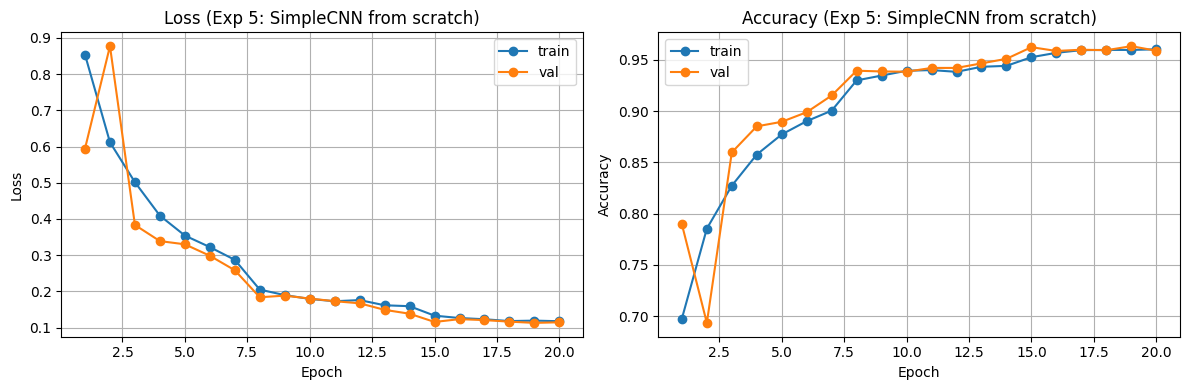

[Exp 5] Test loss 0.120 | Test accuracy 0.961
Saved /content/drive/MyDrive/eurosat/simplecnn_fromscratch.pt


In [26]:
plot_history(history, "Exp 5: SimpleCNN from scratch")
evaluate(model, "Exp 5")
save_checkpoint(model, "simplecnn_fromscratch.pt")

   **Rerun check:** repeating all experiments on a GPU landed within ~1% of the original logged results. The learning-rate gain (~2-3%) is clearly beyond this noise; differences of ~1% (including the accuracy cost of removing augmentation) are not.

In [24]:
exp5 = """EXPERIMENT 5 - FROM-SCRATCH CNN
=================================

Purpose:
    Isolate the value of pretraining. Train a small CNN from random
    initialization on the same data and pipeline as Experiment 2.
    Measure the gap.

Setup:
    Model:      SimpleCNN (4 conv blocks, batch norm, adaptive pooling,
                single linear head). 586,154 parameters.
    Init:       Random (no pretrained weights)
    Dataset:    Same EuroSAT split (70/15/15, seed 42)
    Aug:        Same as Exp 2 (h-flip, v-flip, 90-deg rotation)
    Optimizer:  Adam, lr=1e-3
    Scheduler:  StepLR(step_size=7, gamma=0.3)
    Epochs:     20
    Runtime:    ~3 minutes (GPU)

Result:
    Test loss     0.111
    Test accuracy 0.962  (96.2%)

Comparison to Experiment 2 (pretrained ResNet-18):
    Exp 2 params:             11,181,642
    Exp 5 params:                586,154   (~5.2% of ResNet-18)
    Exp 2 test accuracy:            0.978
    Exp 5 test accuracy:            0.962
    Gap:                           -1.6%

Per-epoch:
    Epoch  1/20 | lr 1.00e-03 | train loss 0.827 acc 0.705 | val loss 0.614 acc 0.777
    Epoch  2/20 | lr 1.00e-03 | train loss 0.578 acc 0.796 | val loss 0.582 acc 0.808
    Epoch  3/20 | lr 1.00e-03 | train loss 0.478 acc 0.833 | val loss 0.436 acc 0.849
    Epoch  4/20 | lr 1.00e-03 | train loss 0.400 acc 0.864 | val loss 0.439 acc 0.856
    Epoch  5/20 | lr 1.00e-03 | train loss 0.361 acc 0.873 | val loss 0.343 acc 0.886
    Epoch  6/20 | lr 1.00e-03 | train loss 0.320 acc 0.890 | val loss 0.257 acc 0.914
    Epoch  7/20 | lr 3.00e-04 | train loss 0.279 acc 0.904 | val loss 0.229 acc 0.922
    Epoch  8/20 | lr 3.00e-04 | train loss 0.194 acc 0.936 | val loss 0.150 acc 0.952
    Epoch  9/20 | lr 3.00e-04 | train loss 0.179 acc 0.938 | val loss 0.138 acc 0.956
    Epoch 10/20 | lr 3.00e-04 | train loss 0.171 acc 0.941 | val loss 0.145 acc 0.948
    Epoch 11/20 | lr 3.00e-04 | train loss 0.163 acc 0.943 | val loss 0.146 acc 0.952
    Epoch 12/20 | lr 3.00e-04 | train loss 0.156 acc 0.946 | val loss 0.152 acc 0.949
    Epoch 13/20 | lr 3.00e-04 | train loss 0.138 acc 0.952 | val loss 0.113 acc 0.962
    Epoch 14/20 | lr 9.00e-05 | train loss 0.150 acc 0.947 | val loss 0.140 acc 0.955
    Epoch 15/20 | lr 9.00e-05 | train loss 0.117 acc 0.959 | val loss 0.098 acc 0.967
    Epoch 16/20 | lr 9.00e-05 | train loss 0.109 acc 0.964 | val loss 0.113 acc 0.964
    Epoch 17/20 | lr 9.00e-05 | train loss 0.109 acc 0.963 | val loss 0.099 acc 0.967
    Epoch 18/20 | lr 9.00e-05 | train loss 0.108 acc 0.964 | val loss 0.097 acc 0.970
    Epoch 19/20 | lr 9.00e-05 | train loss 0.101 acc 0.966 | val loss 0.097 acc 0.967
    Epoch 20/20 | lr 9.00e-05 | train loss 0.105 acc 0.962 | val loss 0.099 acc 0.969

Observations:
    - From-scratch CNN reaches 96.2% -- only 1.6% behind pretrained
      ResNet-18 -- with ~19x fewer parameters.
    - The pretrained model converges much faster: at epoch 1 it was at
      val 0.890 vs from-scratch at val 0.777. Pretraining saves TIME,
      not just accuracy.
    - Final generalization gap is small (train 0.962 vs val 0.969).
      Val > train throughout due to augmentation making training
      examples harder.
    - The "moment of click" happens later in the from-scratch run
      (epoch 6 jump in val) than in the pretrained run (epoch 3).

Conclusion:
    On EuroSAT, pretraining is worth ~1.6% test accuracy and much
    faster convergence. But the dataset's visual simplicity means a
    small CNN trained from scratch is competitive. The value of
    pretraining would be MUCH larger on harder datasets (smaller
    objects, more classes, more visual clutter).

    Useful framing: pretraining buys convergence speed and data
    efficiency, not necessarily a higher ceiling -- at least on easy
    datasets.

Saved model: simplecnn_fromscratch.pt
"""
write_log("exp5_fromscratch_cnn.txt", exp5)

Wrote /content/drive/MyDrive/eurosat/exp5_fromscratch_cnn.txt


## Results: original runs vs this run

In [25]:
ORIGINAL = {"Exp 0": 0.936, "Exp 1": 0.946, "Exp 2": 0.978, "Exp 3": 0.967,
            "Exp 3b": 0.957, "Exp 4": 0.965, "Exp 5": 0.962}

print(f"{'Experiment':<12}{'Original log':>14}{'This run':>11}")
for name, orig in ORIGINAL.items():
    now = results.get(name)
    this_run = f"{now:.3f}" if now is not None else "not run"
    print(f"{name:<12}{orig:>14.3f}{this_run:>11}")

Experiment    Original log   This run
Exp 0                0.936      0.941
Exp 1                0.946      0.954
Exp 2                0.978      0.975
Exp 3                0.967      0.968
Exp 3b               0.957      0.960
Exp 4                0.965      0.970
Exp 5                0.962      0.961


## Conclusion

This project built a working EuroSAT classifier and used it as a testbed
for understanding the training pipeline. Starting from a 93.6% baseline,
a series of controlled experiments reached 97.8% while documenting *why*
each change mattered.

### On hyperparameters

Experiment 2 was the single biggest win: adding a learning rate schedule
lifted accuracy by 3.2%, well beyond run-to-run noise on a 4,050-image
test set. On this dataset, a training-recipe choice mattered more than any
architecture or freezing choice I tested.

### On generalization (Module 1 concept, empirically demonstrated)

Experiment 4 (no augmentation) made the concept concrete: the model
reached 100% training accuracy but only 96.5% on the test set, with a
generalization gap of ~2.8%. The equivalent run *with* augmentation had
a gap of ~0.3%. This is the difference between memorization and
generalization made visible in a plot.

### On transfer learning

Experiment 5 showed that on EuroSAT, pretraining is worth ~1.6% accuracy
and much faster convergence. The value of pretraining is dataset-
dependent: on visually distinct, clean datasets like EuroSAT it is modest;
on cluttered real-world drone imagery it would likely be much larger.

### On freezing

Freezing pretrained layers cost accuracy in a roughly monotonic way:
-1.1% with ~6% of parameters frozen, -2.1% with ~25% frozen (relative to
full fine-tuning). Freezing is a compute/memory trade-off, not a free win.
Because Experiment 3b also introduced the BatchNorm-eval fix, a cleaner
test would rerun Experiment 3 with the fix applied.

### Limitations

Each configuration was run once, and only the data split was seeded in the
original runs. Differences of about 1% (Exp 0 vs 1, Exp 3, Exp 5) are
suggestive rather than conclusive; repeating each run with several seeds
would tighten them.

### Next steps

- Multi-spectral EuroSAT (13 bands instead of 3): tests whether extra
  spectral information improves performance. See the `torchgeo` library.
- Object detection on VisDrone: the natural next project, aligned with
  Module 2 of the drone course.
- Apply the same pipeline to a harder aerial dataset to see how the
  balance between pretraining, augmentation, and freezing shifts.